#**Using Python libraries for Handling WaPOR Data**

[![](https://raw.githubusercontent.com//wateraccounting/WaPORMOOC/main/images/colab-badge.png)](https://colab.research.google.com/github/wateraccounting/WaPORMOOC/blob/main/3_Python_for_WaPOR/N05_Plotting_Zonal_Statistics.ipynb?target="_blank")

#Notebook 5: Calculating and visualising zonal statistics for multiple seasons

In this Notebook we will show you how to run a script developed for the WaPOR project that calculates zonal statistics for multiple seasons. And to visualise the results (TBP over AETI).   
The steps are:
1. Install and load necessary Python Libraries to manage raster files
2. Create DataFrame of zonal statistics of AETI and TBP for each farm and each season
3. Merge DataFrames and visualise scatterplots of AETI and TBP.
4. Exercises (needed for MOOC quiz)


**Data needed**:

For the exercises of the [MOOC Python for geospatial analyses using WaPOR data](https://ocw.un-ihe.org/course/view.php?id=272) you can use the following data:

* **Area**: Farm boundaries in Wad Helal irrigation block. For this exercise you need a .shp file of the WH_fields.geojson used in the previous notebook.

* **TIFF files**: seasonal TIFF files of TBP and AETI saved after running [Notebook 4 : Seasonal Aggregation and WP](https://github.com/wateraccounting/WaPORMOOC/blob/main/3_Python_for_WaPOR/N04_Seasonal_Aggregation_and_WP.ipynb)

Save these files on google drive in a folder `Python_mooc` in the main drive.

 © 2024 IHE Delft Licenced under CC BY SA Creative Commons


---

## Step 1 - Import modules/libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install rioxarray --quiet
!pip install rasterstats --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00


In [3]:
import os                                 # a module for interacting with the operating system
import sys
import glob                               # used to retrieve files/pathnames matching a specified pattern
import re                                 # re sub() module can be used to replace substring
import rioxarray as rio
import pandas as pd                       # to store and manipulate tabular data in rows of observations and columns of variables
import numpy as np                        # stands for 'Numerical Python, is a python library used for scientific computing with arrays
import calendar
import datetime
import matplotlib.pyplot as plt            # is a plotting library used for 2D graphics in python
from osgeo import gdal
from osgeo import osr
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt
import geopandas as gpd
from rasterstats import zonal_stats

In [4]:
# define seasons
season_periods = {
    'season1': {'SOS': '2020-10-01', 'EOS': '2021-04-30'},
    'season2': {'SOS': '2021-10-01', 'EOS': '2022-04-30'},
    'season3': {'SOS': '2022-10-01', 'EOS': '2023-04-30'}
}

# Step 2 - Calculate zonal Statistics

The following scripts load the TBP seasonal data you saved from the Notebook 03 exercises (first Code cell) and calculates the zonal statistics for each farm (second Code cell). Check if the .csv file is created in your folder. Adapt the first Code cell to calculate zonal statistics for seasonal AETI by running both scripts.

**NOTE**: The file for the farms in this script is a .shp file. Create a .shp file from the geojson file in QGIS first. Dont forget to upload all dependencies in the same folder!

In [8]:
from google.colab import files

uploaded = files.upload()

Saving WH_fields.zip to WH_fields.zip


In [9]:
import zipfile
import os

zip_path = "/content/WH_fields.zip"
extract_folder = "/content/WH_fields"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Extracted files:")
for root, dirs, filenames in os.walk(extract_folder):
    for filename in filenames:
        print(os.path.join(root, filename))

Extracted files:
/content/WH_fields/WH_Fields/WH_Fields.prj
/content/WH_fields/WH_Fields/WH_Fields.cpg
/content/WH_fields/WH_Fields/WH_Fields.dbf
/content/WH_fields/WH_Fields/WH_Fields.shx
/content/WH_fields/WH_Fields/WH_Fields.shp
/content/WH_fields/WH_Fields/WH_Fields.qmd


In [12]:
shapefile_path = "/content/WH_fields/WH_Fields/WH_Fields.shp"

import geopandas as gpd

gdf = gpd.read_file(shapefile_path)

print("Shapefile loaded successfully!")
print("Number of farms:", len(gdf))
print("Columns:", gdf.columns.tolist())
print("CRS:", gdf.crs)

gdf.head()

Shapefile loaded successfully!
Number of farms: 214
Columns: ['id', 'yield', 'layer', 'path', 'geometry']
CRS: EPSG:32636


,id,yield,layer,path,geometry
0,3201,3.31,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,"POLYGON ((518802.239 1582439.322, 518814.019 1..."
1,3202,3.10,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,"POLYGON ((518813.176 1582497.245, 518826.226 1..."
2,3203,2.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,"POLYGON ((518827.493 1582553.491, 518840.966 1..."
3,3204,3.30,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,"POLYGON ((518838.855 1582607.637, 518846.432 1..."
4,3205,3.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,"POLYGON ((518847.277 1582639.538, 518853.589 1..."


In [13]:
folder_path = '/content/drive/MyDrive/Python_mooc/Data/TBP_season'                # path to the folder with raster files
shapefile_path = "/content/drive/MyDrive/Python_mooc/Data/WH_fields.shp"       # path to shapefile
output_path = '/content/drive/MyDrive/Python_mooc/Data'                            # path to the output folder
output_file = 'TBP_per_field.csv'                                              # name of the output file

In [14]:
import os

# Check whether Google Drive is mounted
drive_path = "/content/drive/MyDrive"

print("Google Drive mounted:", os.path.exists(drive_path))

# Search for the shapefile
search_root = "/content/drive/MyDrive"

for root, dirs, files in os.walk(search_root):
    for file in files:
        if file.lower() == "wh_fields.shp":
            print("Shapefile found:", os.path.join(root, file))

Google Drive mounted: True


In [16]:
import os
import glob
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

shapefile_path = "/content/WH_fields/WH_Fields/WH_Fields.shp"

# Seasonal TBP
folder_path = "/content/content/output/TBP_season"

output_path = "/content/content/output/Zonal_Statistics"
output_file = "TBP_zonal_statistics.csv"

In [18]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            if "TBP" in file.upper() or "AETI" in file.upper():
                print(os.path.join(root, file))

/content/drive/MyDrive/Python_mooc/Data/AETI_season/AETIseason1_2020-10-01_to_2021-04-30.tif
/content/drive/MyDrive/Python_mooc/Data/AETI_season/AETIseason2_2021-10-01_to_2022-04-30.tif
/content/drive/MyDrive/Python_mooc/Data/AETI_season/AETIseason3_2022-10-01_to_2023-04-30.tif


In [19]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
shapefile_path = "/content/WH_fields/WH_Fields/WH_Fields.shp"

folder_path = "/content/drive/MyDrive/Python_mooc/Data/AETI_season"

output_path = "/content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics"

output_file = "AETI_zonal_statistics.csv"

In [23]:
import os
import glob
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

# Load the farm boundaries
gdf = gpd.read_file(shapefile_path)

# Remove missing or empty geometries
gdf = gdf.dropna(subset=["geometry"]).copy()
gdf = gdf[~gdf.geometry.is_empty].copy()

print("Number of farms:", len(gdf))
print("Farm CRS:", gdf.crs)

# Find seasonal AETI rasters
tif_files = sorted(glob.glob(os.path.join(folder_path, "*.tif")))
print("AETI rasters found:", len(tif_files))

if not tif_files:
    raise FileNotFoundError(f"No TIFF files found in {folder_path}")

# Copy farm attributes into the results table
results_gdf = gdf.copy()

# Process each seasonal AETI raster
for tif_file in tif_files:
    try:
        with rasterio.open(tif_file) as src:
            if src.crs is None or gdf.crs is None:
                raise ValueError("Raster or shapefile CRS is missing.")

            # Match the farm CRS to the raster CRS
            farms = gdf if gdf.crs == src.crs else gdf.to_crs(src.crs)

            stats = zonal_stats(
                farms,
                tif_file,
                stats=["mean"],
                nodata=src.nodata
            )

        # Use the full raster filename as the column name
        identifier = os.path.splitext(os.path.basename(tif_file))[0]

        results_gdf[identifier] = [
            s["mean"] if s and s["mean"] is not None else None
            for s in stats
        ]

        print("Processed:", identifier)

    except Exception as e:
        print(f"Failed to process {tif_file}: {e}")

# Save results as CSV
os.makedirs(output_path, exist_ok=True)

csv_path = os.path.join(output_path, output_file)

results_gdf.drop(columns=["geometry"]).to_csv(
    csv_path,
    index=False
)

print("\nAETI zonal statistics saved to:")
print(csv_path)

Number of farms: 212
Farm CRS: EPSG:32636
AETI rasters found: 3
Processed: AETIseason1_2020-10-01_to_2021-04-30
Processed: AETIseason2_2021-10-01_to_2022-04-30
Processed: AETIseason3_2022-10-01_to_2023-04-30

AETI zonal statistics saved to:
/content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics/AETI_zonal_statistics.csv


In [24]:

import os
import glob
import numpy as np
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

# File locations
shapefile_path = "/content/WH_fields/WH_Fields/WH_Fields.shp"
aeti_folder = "/content/drive/MyDrive/Python_mooc/Data/AETI_season"

season2_aeti = os.path.join(
    aeti_folder,
    "AETIseason2_2021-10-01_to_2022-04-30.tif"
)

# Load farm boundaries
gdf = gpd.read_file(shapefile_path)

# Find the farm ID column
print("Available shapefile columns:", gdf.columns.tolist())

id_candidates = [
    c for c in gdf.columns
    if c.lower().replace("_", "").replace(" ", "")
    in ["farmid", "idfarm", "id"]
]

if not id_candidates:
    raise ValueError(
        "Could not identify the farm ID column. "
        "Check the printed columns and set the correct column name."
    )

id_col = id_candidates[0]
farm = gdf[
    gdf[id_col].astype(str).str.strip() == "2212"
]

if farm.empty:
    raise ValueError(
        f"Farm 2212 not found using column '{id_col}'. "
        "Check the farm IDs in the shapefile."
    )

print("Farm ID column:", id_col)
print("Matching farm records:", len(farm))

# Calculate Season 2 AETI
with rasterio.open(season2_aeti) as src:
    farm_raster_crs = (
        farm if farm.crs == src.crs else farm.to_crs(src.crs)
    )

    aeti_stats = zonal_stats(
        farm_raster_crs,
        season2_aeti,
        stats=["mean"],
        nodata=src.nodata
    )

aeti_mean = aeti_stats[0]["mean"]

if aeti_mean is None:
    print("No valid AETI pixels intersect Farm 2212.")
else:
    print(f"\nFarm 2212 Season 2 mean AETI: {aeti_mean:.0f} mm/season")

# Search for seasonal TBP rasters
search_roots = ["/content", "/content/drive/MyDrive/Python_mooc/Data"]
tbp_files = []

for root in search_roots:
    for path in glob.glob(os.path.join(root, "**", "*.tif"), recursive=True):
        if "tbp" in os.path.basename(path).lower():
            if "season2" in os.path.basename(path).lower():
                tbp_files.append(path)

tbp_files = sorted(set(tbp_files))

print("\nSeason 2 TBP rasters found:")
for path in tbp_files:
    print(path)

if not tbp_files:
    print(
        "\nTBP raster not found. We need to locate or recreate "
        "the seasonal TBP raster before answering the second question."
    )
else:
    tbp_file = tbp_files[0]

    with rasterio.open(tbp_file) as src:
        farm_raster_crs = (
            farm if farm.crs == src.crs else farm.to_crs(src.crs)
        )

        tbp_stats = zonal_stats(
            farm_raster_crs,
            tbp_file,
            stats=["mean"],
            nodata=src.nodata
        )

    tbp_mean = tbp_stats[0]["mean"]

    if tbp_mean is None:
        print("No valid TBP pixels intersect Farm 2212.")
    else:
        print(f"Farm 2212 Season 2 mean TBP: {tbp_mean:.1f} ton/ha")


Available shapefile columns: ['id', 'yield', 'layer', 'path', 'geometry']
Farm ID column: id
Matching farm records: 1

Farm 2212 Season 2 mean AETI: 446 mm/season

Season 2 TBP rasters found:

TBP raster not found. We need to locate or recreate the seasonal TBP raster before answering the second question.


In [28]:
import os

base = "/content/drive/MyDrive/Python_mooc"

for current_dir, subdirs, files in os.walk(base):
    print(f"\nFolder: {current_dir}")

    for filename in files:
        if any(term in filename.lower()
               for term in ["npp", "wapor", "output", "zip"]):
            print("  ", filename)


Folder: /content/drive/MyDrive/Python_mooc

Folder: /content/drive/MyDrive/Python_mooc/Data

Folder: /content/drive/MyDrive/Python_mooc/Data/AETI_season

Folder: /content/drive/MyDrive/Python_mooc/Data/NPP_season

Folder: /content/drive/MyDrive/Python_mooc/Data/TBP_season

Folder: /content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics


In [30]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename, content in uploaded.items():
    print(f"{filename}: {len(content) / (1024**2):.2f} MB")

Saving data.zip to data.zip

Uploaded files:
data.zip: 64.15 MB


In [33]:
import zipfile
import os

zip_path = "/content/data.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    all_files = z.namelist()

    print(f"Total items in ZIP: {len(all_files)}")
    print("\nFirst 40 items:")

    for name in all_files[:40]:
        print(name)

    print("\nFile type summary:")
    print("TIFF files:", sum(
        name.lower().endswith((".tif", ".tiff"))
        for name in all_files
    ))
    print("Nested ZIP files:", sum(
        name.lower().endswith(".zip")
        for name in all_files
    ))

Total items in ZIP: 189

First 40 items:
content/output/
content/output/L3-NPP-D/
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2022-05-21.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2023-01-11.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-11-11.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2022-02-11.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2021-03-01.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2021-05-21.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2022-04-21.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2021-11-21.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2022-04-01.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2021-10-01.tif
content/output/L3-NPP-D/Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2021-10-21.tif
conte

In [34]:
import os
import zipfile

zip_path = "/content/data.zip"
extract_to = "/content"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_to)

print("Extraction completed.")

# Check the expected product folders
for folder in [
    "/content/content/output/L3-AETI-D",
    "/content/content/output/L3-NPP-D"
]:
    print(f"\nFolder: {folder}")

    if os.path.exists(folder):
        rasters = [
            f for f in os.listdir(folder)
            if f.lower().endswith((".tif", ".tiff"))
        ]
        print("Raster count:", len(rasters))
        for filename in sorted(rasters)[:5]:
            print(" ", filename)
    else:
        print("Folder not found.")

Extraction completed.

Folder: /content/content/output/L3-AETI-D
Raster count: 93
  Wad_Helal.GEZ_L3-AETI-D_NONE_dekad_converted_2020-10-01.tif
  Wad_Helal.GEZ_L3-AETI-D_NONE_dekad_converted_2020-10-11.tif
  Wad_Helal.GEZ_L3-AETI-D_NONE_dekad_converted_2020-10-21.tif
  Wad_Helal.GEZ_L3-AETI-D_NONE_dekad_converted_2020-11-01.tif
  Wad_Helal.GEZ_L3-AETI-D_NONE_dekad_converted_2020-11-11.tif

Folder: /content/content/output/L3-NPP-D
Raster count: 93
  Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-10-01.tif
  Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-10-11.tif
  Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-10-21.tif
  Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-11-01.tif
  Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-11-11.tif


In [35]:

import os
import re
from datetime import datetime

output_dir = "/content/content/output"

seasons = {
    "Season 1": ("2020-10-01", "2021-04-30"),
    "Season 2": ("2021-10-01", "2022-04-30"),
    "Season 3": ("2022-10-01", "2023-04-30"),
}

for product in ["L3-AETI-D", "L3-NPP-D"]:
    folder = os.path.join(output_dir, product)
    dates = []

    for filename in os.listdir(folder):
        if filename.lower().endswith((".tif", ".tiff")):
            match = re.search(
                r"(\d{4}-\d{2}-\d{2})\.tiff?$",
                filename,
                re.IGNORECASE
            )
            if match:
                dates.append(
                    datetime.strptime(match.group(1), "%Y-%m-%d")
                )

    dates.sort()
    print(f"\n{product}: {len(dates)} total rasters")

    for season, (start, end) in seasons.items():
        start_date = datetime.strptime(start, "%Y-%m-%d")
        end_date = datetime.strptime(end, "%Y-%m-%d")
        selected = [d for d in dates if start_date <= d <= end_date]

        print(f"{season} ({start} to {end}): {len(selected)} rasters")
        if selected:
            print(
                f"  First: {selected[0].date()} | "
                f"Last: {selected[-1].date()}"
            )



L3-AETI-D: 93 total rasters
Season 1 (2020-10-01 to 2021-04-30): 21 rasters
  First: 2020-10-01 | Last: 2021-04-21
Season 2 (2021-10-01 to 2022-04-30): 21 rasters
  First: 2021-10-01 | Last: 2022-04-21
Season 3 (2022-10-01 to 2023-04-30): 21 rasters
  First: 2022-10-01 | Last: 2023-04-21

L3-NPP-D: 93 total rasters
Season 1 (2020-10-01 to 2021-04-30): 21 rasters
  First: 2020-10-01 | Last: 2021-04-21
Season 2 (2021-10-01 to 2022-04-30): 21 rasters
  First: 2021-10-01 | Last: 2022-04-21
Season 3 (2022-10-01 to 2023-04-30): 21 rasters
  First: 2022-10-01 | Last: 2023-04-21


In [36]:

import os
import glob
import numpy as np
import rasterio

folders = {
    "AETI": "/content/content/output/L3-AETI-D",
    "NPP": "/content/content/output/L3-NPP-D",
}

sample_files = {}

for product, folder in folders.items():
    files = sorted(glob.glob(os.path.join(folder, "*.tif")))
    if not files:
        raise FileNotFoundError(f"No TIFF files found in {folder}")

    sample_files[product] = files[0]

    with rasterio.open(files[0]) as src:
        arr = src.read(1, masked=True)
        valid = arr.compressed()

        print(f"\n{'='*15} {product} {'='*15}")
        print("Sample file:", os.path.basename(files[0]))
        print("CRS:", src.crs)
        print("Dimensions:", src.width, "x", src.height)
        print("Data type:", src.dtypes[0])
        print("NoData:", src.nodata)
        print("Band descriptions:", src.descriptions)
        print("Units:", src.units)
        print("Tags:", src.tags())

        if valid.size:
            print("Valid pixel minimum:", float(valid.min()))
            print("Valid pixel maximum:", float(valid.max()))
            print("Valid pixel mean:", float(valid.mean()))

with rasterio.open(sample_files["AETI"]) as a, \
     rasterio.open(sample_files["NPP"]) as n:
    print("\nDo AETI and NPP grids match?")
    print("Same CRS:", a.crs == n.crs)
    print("Same dimensions:", (a.width, a.height) == (n.width, n.height))
    print("Same transform:", a.transform == n.transform)



=============== AETI ===============
Sample file: Wad_Helal.GEZ_L3-AETI-D_NONE_dekad_converted_2020-10-01.tif
CRS: EPSG:32636
Dimensions: 754 x 460
Data type: float64
NoData: -9999.0
Band descriptions: ('Actual EvapoTranspiration and Interception',)
Units: (None,)
Tags: {'AREA_OR_POINT': 'Area'}
Valid pixel minimum: 3.0
Valid pixel maximum: 71.0
Valid pixel mean: 30.811319468702344

=============== NPP ===============
Sample file: Wad_Helal.GEZ_L3-NPP-D_NONE_dekad_converted_2020-10-01.tif
CRS: EPSG:32636
Dimensions: 754 x 460
Data type: float64
NoData: -9999.0
Band descriptions: ('Net Primary Production',)
Units: (None,)
Tags: {'AREA_OR_POINT': 'Area'}
Valid pixel minimum: 0.0
Valid pixel maximum: 24.09
Valid pixel mean: 6.411093437161869

Do AETI and NPP grids match?
Same CRS: True
Same dimensions: True
Same transform: True


In [37]:

import os
import glob
import re
import numpy as np
import rasterio
from datetime import datetime

# Source folders
sources = {
    "AETI": "/content/content/output/L3-AETI-D",
    "NPP": "/content/content/output/L3-NPP-D",
}

# Output folders in Google Drive
base = "/content/drive/MyDrive/Python_mooc/Data"

outputs = {
    "AETI": os.path.join(base, "AETI_season"),
    "NPP": os.path.join(base, "NPP_season"),
}

for folder in outputs.values():
    os.makedirs(folder, exist_ok=True)

seasons = {
    "season1": ("2020-10-01", "2021-04-30"),
    "season2": ("2021-10-01", "2022-04-30"),
    "season3": ("2022-10-01", "2023-04-30"),
}

def get_raster_date(path):
    match = re.search(
        r"(\d{4}-\d{2}-\d{2})\.tiff?$",
        os.path.basename(path),
        re.IGNORECASE
    )
    if not match:
        return None
    return datetime.strptime(match.group(1), "%Y-%m-%d").date()

for product, source_folder in sources.items():
    raster_paths = glob.glob(
        os.path.join(source_folder, "*.tif")
    )

    for season_name, (start, end) in seasons.items():
        start_date = datetime.strptime(start, "%Y-%m-%d").date()
        end_date = datetime.strptime(end, "%Y-%m-%d").date()

        selected = [
            path for path in raster_paths
            if (get_raster_date(path) is not None)
            and start_date <= get_raster_date(path) <= end_date
        ]
        selected.sort(key=get_raster_date)

        if len(selected) != 21:
            raise ValueError(
                f"{product} {season_name}: expected 21 rasters, "
                f"found {len(selected)}"
            )

        with rasterio.open(selected[0]) as src:
            profile = src.profile.copy()
            nodata = src.nodata
            total = np.zeros(
                (src.height, src.width), dtype=np.float64
            )
            valid_count = np.zeros(
                (src.height, src.width), dtype=np.uint16
            )

        for path in selected:
            with rasterio.open(path) as src:
                data = src.read(1).astype(np.float64)
                valid = np.isfinite(data)

                if src.nodata is not None:
                    valid &= data != src.nodata

                total[valid] += data[valid]
                valid_count[valid] += 1

        # Only keep pixels with valid observations
        # across all 21 dekads for a complete seasonal total.
        total[valid_count != 21] = nodata

        output_path = os.path.join(
            outputs[product],
            f"{product}{season_name}_{start}_to_{end}.tif"
        )

        profile.update(
            dtype="float64",
            count=1,
            nodata=nodata,
            compress="lzw"
        )

        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(total, 1)

        valid_values = total[total != nodata]
        print(
            f"{product} {season_name}: {len(selected)} dekads "
            f"-> {output_path}"
        )
        print(
            f"  Valid pixels: {valid_values.size:,}; "
            f"mean: {valid_values.mean():.2f}; "
            f"maximum: {valid_values.max():.2f}"
        )

print("\nSeasonal aggregation completed.")


AETI season1: 21 dekads -> /content/drive/MyDrive/Python_mooc/Data/AETI_season/AETIseason1_2020-10-01_to_2021-04-30.tif
  Valid pixels: 117,373; mean: 642.93; maximum: 1340.20


AETI season2: 21 dekads -> /content/drive/MyDrive/Python_mooc/Data/AETI_season/AETIseason2_2021-10-01_to_2022-04-30.tif
  Valid pixels: 117,373; mean: 627.17; maximum: 1399.50


AETI season3: 21 dekads -> /content/drive/MyDrive/Python_mooc/Data/AETI_season/AETIseason3_2022-10-01_to_2023-04-30.tif
  Valid pixels: 117,373; mean: 596.05; maximum: 1360.60


NPP season1: 21 dekads -> /content/drive/MyDrive/Python_mooc/Data/NPP_season/NPPseason1_2020-10-01_to_2021-04-30.tif
  Valid pixels: 117,373; mean: 191.43; maximum: 429.24


NPP season2: 21 dekads -> /content/drive/MyDrive/Python_mooc/Data/NPP_season/NPPseason2_2021-10-01_to_2022-04-30.tif
  Valid pixels: 117,373; mean: 197.77; maximum: 485.60


NPP season3: 21 dekads -> /content/drive/MyDrive/Python_mooc/Data/NPP_season/NPPseason3_2022-10-01_to_2023-04-30.tif
  Valid pixels: 117,373; mean: 182.22; maximum: 435.88

Seasonal aggregation completed.


In [38]:

import os
import numpy as np
import rasterio

base = "/content/drive/MyDrive/Python_mooc/Data"
npp_folder = os.path.join(base, "NPP_season")
tbp_folder = os.path.join(base, "TBP_season")
os.makedirs(tbp_folder, exist_ok=True)

seasons = {
    "season1": ("2020-10-01", "2021-04-30"),
    "season2": ("2021-10-01", "2022-04-30"),
    "season3": ("2022-10-01", "2023-04-30"),
}

for season_name, (start, end) in seasons.items():
    npp_path = os.path.join(
        npp_folder,
        f"NPP{season_name}_{start}_to_{end}.tif"
    )

    tbp_path = os.path.join(
        tbp_folder,
        f"TBP{season_name}_{start}_to_{end}.tif"
    )

    with rasterio.open(npp_path) as src:
        npp = src.read(1).astype(np.float64)
        profile = src.profile.copy()
        nodata = src.nodata

        valid = np.isfinite(npp)
        if nodata is not None:
            valid &= npp != nodata

        tbp = np.full(npp.shape, -9999.0, dtype=np.float32)
        tbp[valid] = ((npp[valid] * 22.222) / 1000).astype(np.float32)

        profile.update(
            dtype="float32",
            count=1,
            nodata=-9999.0,
            compress="lzw",
            tiled=False
        )
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)

        with rasterio.open(tbp_path, "w", **profile) as dst:
            dst.write(tbp, 1)

        values = tbp[valid]
        print(f"\n{season_name}: {tbp_path}")
        print(f"Mean TBP across raster: {values.mean():.2f}")
        print(f"Maximum TBP: {values.max():.2f} ton/ha")

print("\nSeasonal TBP rasters created.")



season1: /content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason1_2020-10-01_to_2021-04-30.tif
Mean TBP across raster: 4.25
Maximum TBP: 9.54 ton/ha

season2: /content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason2_2021-10-01_to_2022-04-30.tif
Mean TBP across raster: 4.39
Maximum TBP: 10.79 ton/ha

season3: /content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason3_2022-10-01_to_2023-04-30.tif
Mean TBP across raster: 4.05
Maximum TBP: 9.69 ton/ha

Seasonal TBP rasters created.


In [39]:

import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

shapefile_path = "/content/WH_fields/WH_Fields/WH_Fields.shp"
tbp_path = (
    "/content/drive/MyDrive/Python_mooc/Data/TBP_season/"
    "TBPseason2_2021-10-01_to_2022-04-30.tif"
)

gdf = gpd.read_file(shapefile_path)
farm = gdf[gdf["id"].astype(str).str.strip() == "2212"]

if farm.empty:
    raise ValueError("Farm 2212 was not found.")

with rasterio.open(tbp_path) as src:
    farm_projected = (
        farm if farm.crs == src.crs else farm.to_crs(src.crs)
    )

    stats = zonal_stats(
        farm_projected,
        tbp_path,
        stats=["mean"],
        nodata=src.nodata,
        all_touched=False
    )

tbp_mean = stats[0]["mean"]

if tbp_mean is None:
    print("No valid TBP pixels intersect Farm 2212.")
else:
    print(f"Farm 2212 Season 2 mean TBP: {tbp_mean:.1f} ton/ha")


Farm 2212 Season 2 mean TBP: 2.1 ton/ha


<div class="alert alert-success">

**Exercise 1**:

View the data frame (what are the attributes of these files?)

Extract all values for farms within the FakiMusa6 tertiary unit. What is the seasonal AETI or TBP of farm id 2212 for the season 2? Round AETI to the nearest integer and TBP with one decimal.

Note down the value, you need it for the MOOC quiz!
</div>


In [ ]:
# use pandas to read .csv file

# write code to extract data



# Step 3 - Plot results

We now want to create a scatter plot and therefore we have to merge the two files, which is done with the script below.

In [45]:
import os

base_path = '/content/drive/MyDrive/Python_mooc/Data'

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics/AETI_zonal_statistics.csv


In [48]:
import pandas as pd
import matplotlib.pyplot as plt

aeti_path = '/content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics/AETI_zonal_statistics.csv'

aeti_data = pd.read_csv(aeti_path)

print("Shape:", aeti_data.shape)
print("Columns:", aeti_data.columns.tolist())

display(aeti_data.head())

Shape: (212, 7)
Columns: ['id', 'yield', 'layer', 'path', 'AETIseason1_2020-10-01_to_2021-04-30', 'AETIseason2_2021-10-01_to_2022-04-30', 'AETIseason3_2022-10-01_to_2023-04-30']


,id,yield,layer,path,AETIseason1_2020-10-01_to_2021-04-30,AETIseason2_2021-10-01_to_2022-04-30,AETIseason3_2022-10-01_to_2023-04-30
0,3201,3.31,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,701.692308,528.279487,719.130769
1,3202,3.10,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,725.018919,515.845946,775.375676
2,3203,2.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,784.944118,555.411765,796.317647
3,3204,3.30,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,771.600000,603.810000,784.365000
4,3205,3.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,798.375000,599.495000,764.680000


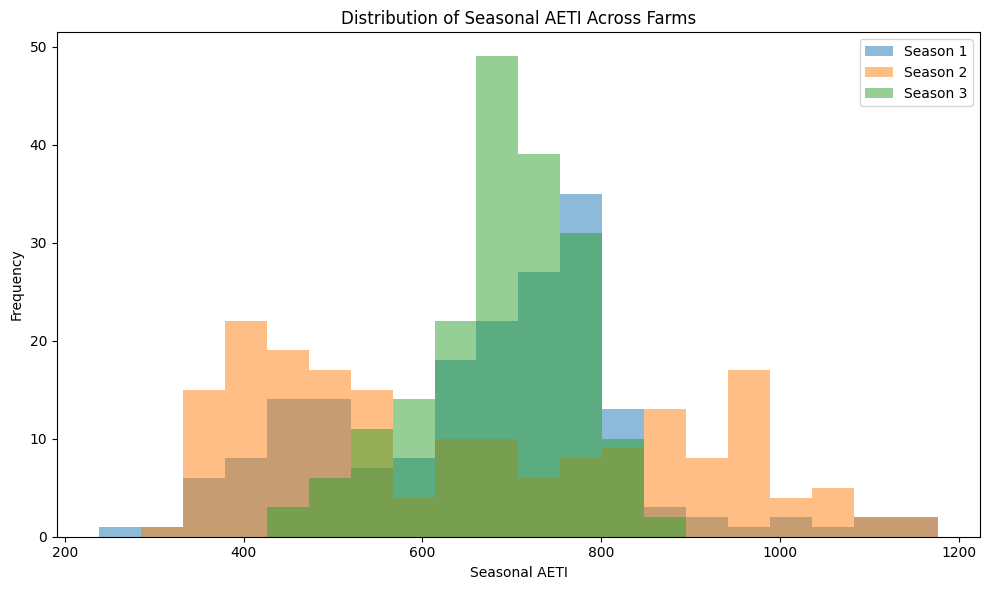

In [49]:

import pandas as pd
import matplotlib.pyplot as plt

aeti_path = '/content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics/AETI_zonal_statistics.csv'
aeti_data = pd.read_csv(aeti_path)

season_cols = [
    'AETIseason1_2020-10-01_to_2021-04-30',
    'AETIseason2_2021-10-01_to_2022-04-30',
    'AETIseason3_2022-10-01_to_2023-04-30'
]

# Plot the distribution of AETI values for each season
aeti_data[season_cols].plot(
    kind='hist',
    bins=20,
    alpha=0.5,
    figsize=(10, 6)
)

plt.title('Distribution of Seasonal AETI Across Farms')
plt.xlabel('Seasonal AETI')
plt.ylabel('Frequency')
plt.legend(['Season 1', 'Season 2', 'Season 3'])
plt.tight_layout()
plt.show()


Columns available for plotting: ['yield', 'AETIseason1_2020-10-01_to_2021-04-30', 'AETIseason2_2021-10-01_to_2022-04-30', 'AETIseason3_2022-10-01_to_2023-04-30']


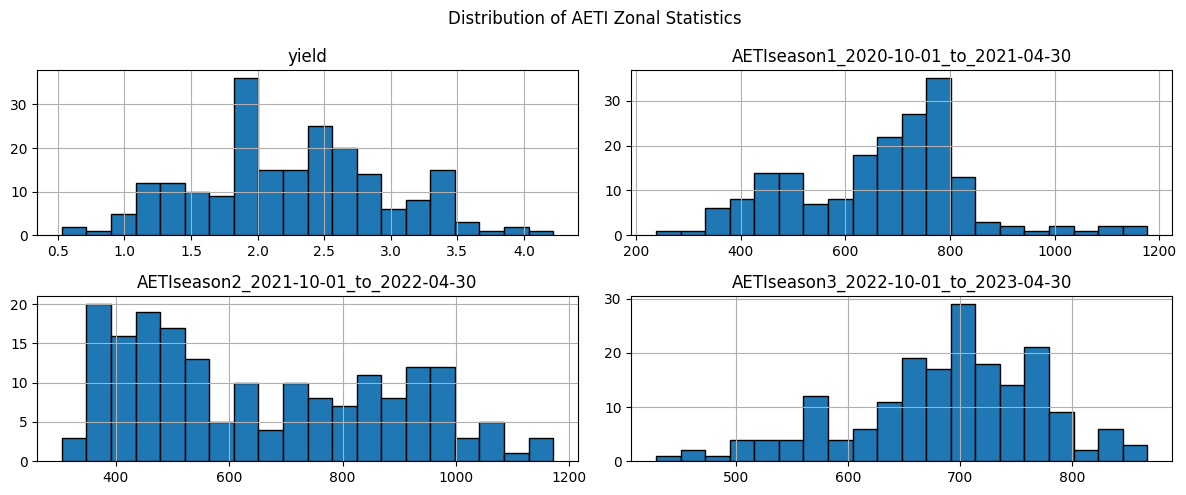

In [47]:
numeric_cols = aeti_data.select_dtypes(include='number').columns.tolist()

# Exclude farm ID from the plots
plot_cols = [col for col in numeric_cols if col.lower() != 'id']

print("Columns available for plotting:", plot_cols)

if plot_cols:
    aeti_data[plot_cols].hist(
        bins=20,
        figsize=(12, 5),
        edgecolor='black'
    )
    plt.suptitle('Distribution of AETI Zonal Statistics')
    plt.tight_layout()
    plt.show()
else:
    print("No numerical AETI columns found. Check the column names.")

In [51]:
import os

search_path = '/content/drive/MyDrive/Python_mooc/Data'

for root, dirs, files in os.walk(search_path):
    for file in files:
        if file.lower().endswith('.tif') and 'tbp' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason1_2020-10-01_to_2021-04-30.tif
/content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason2_2021-10-01_to_2022-04-30.tif
/content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason3_2022-10-01_to_2023-04-30.tif


In [53]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.lower().endswith('.shp') or file.lower() == 'wh_fields.zip':
            print(os.path.join(root, file))

/content/WH_fields.zip
/content/drive/MyDrive/SWAT_DATA/NGA_adm/NGA_adm0.shp
/content/drive/MyDrive/SWAT_DATA/NGA_adm/NGA_adm2.shp
/content/drive/MyDrive/SWAT_DATA/NGA_adm/NGA_adm1.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/WDREACH.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/LFP.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/subs1.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/monitoring_points1.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/outlets1.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/riv1.shp
/content/drive/MyDrive/Carr_SWAT/Watershed/Shapes/hru1.shp
/content/drive/MyDrive/af_bas_ll_r500m/Nigeria Map.shp
/content/drive/MyDrive/af_bas_ll_r500m/af_bas_ll_r500m.UTM Zone 31, Northern Hemisphere.shp
/content/drive/MyDrive/af_bas_ll_r500m/af_bas_ll_r500m.shp
/content/drive/MyDrive/af_bas_ll_r500m/asa.shp
/content/drive/MyDrive/af_bas_ll_r500m/ilorin.shp
/content/drive/MyDrive/af_bas_ll_r500m/WATERSHED3.shp
/content/WH_fields/WH_Fi

In [54]:
shapefile_path = '/content/content/WH_fields/WH_Fields.shp'

In [56]:

import os
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats

shapefile_path = '/content/WH_fields/WH_Fields/WH_Fields.shp'

tbp_rasters = {
    'TBPseason1_2020-10-01_to_2021-04-30':
        '/content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason1_2020-10-01_to_2021-04-30.tif',
    'TBPseason2_2021-10-01_to_2022-04-30':
        '/content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason2_2021-10-01_to_2022-04-30.tif',
    'TBPseason3_2022-10-01_to_2023-04-30':
        '/content/drive/MyDrive/Python_mooc/Data/TBP_season/TBPseason3_2022-10-01_to_2023-04-30.tif'
}

# Load farm polygons
gdf = gpd.read_file(shapefile_path)

print("Original farm records:", len(gdf))
print("Missing geometries:", gdf.geometry.isna().sum())
print("Empty geometries:", gdf.geometry.is_empty.sum())

# Remove missing and empty geometries
gdf = gdf[
    gdf.geometry.notna() & ~gdf.geometry.is_empty
].copy()

# Remove invalid geometries if any remain
gdf = gdf[gdf.geometry.is_valid].copy()

print("Valid farm records:", len(gdf))

# Preserve farm attributes
tbp_data = gdf.drop(columns='geometry').copy()

for col, raster_path in tbp_rasters.items():
    with rasterio.open(raster_path) as src:
        farms = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf

        stats = zonal_stats(
            farms.geometry,
            raster_path,
            stats=['mean'],
            nodata=src.nodata,
            all_touched=False
        )

    tbp_data[col] = [item['mean'] for item in stats]

# Save results
output_path = (
    '/content/drive/MyDrive/Python_mooc/Data/'
    'Zonal_Statistics/TBP_zonal_statistics.csv'
)

os.makedirs(os.path.dirname(output_path), exist_ok=True)
tbp_data.to_csv(output_path, index=False)

print("\nSaved:", output_path)
print("Columns:", tbp_data.columns.tolist())
display(tbp_data.head())


Original farm records: 214
Missing geometries: 2
Empty geometries: 0
Valid farm records: 212

Saved: /content/drive/MyDrive/Python_mooc/Data/Zonal_Statistics/TBP_zonal_statistics.csv
Columns: ['id', 'yield', 'layer', 'path', 'TBPseason1_2020-10-01_to_2021-04-30', 'TBPseason2_2021-10-01_to_2022-04-30', 'TBPseason3_2022-10-01_to_2023-04-30']


,id,yield,layer,path,TBPseason1_2020-10-01_to_2021-04-30,TBPseason2_2021-10-01_to_2022-04-30,TBPseason3_2022-10-01_to_2023-04-30
0,3201,3.31,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.142463,4.009081,5.356982
1,3202,3.10,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.234155,4.046282,5.746220
2,3203,2.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.884422,4.395098,6.155903
3,3204,3.30,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.772654,5.004028,5.914560
4,3205,3.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,6.042064,4.937746,5.634186


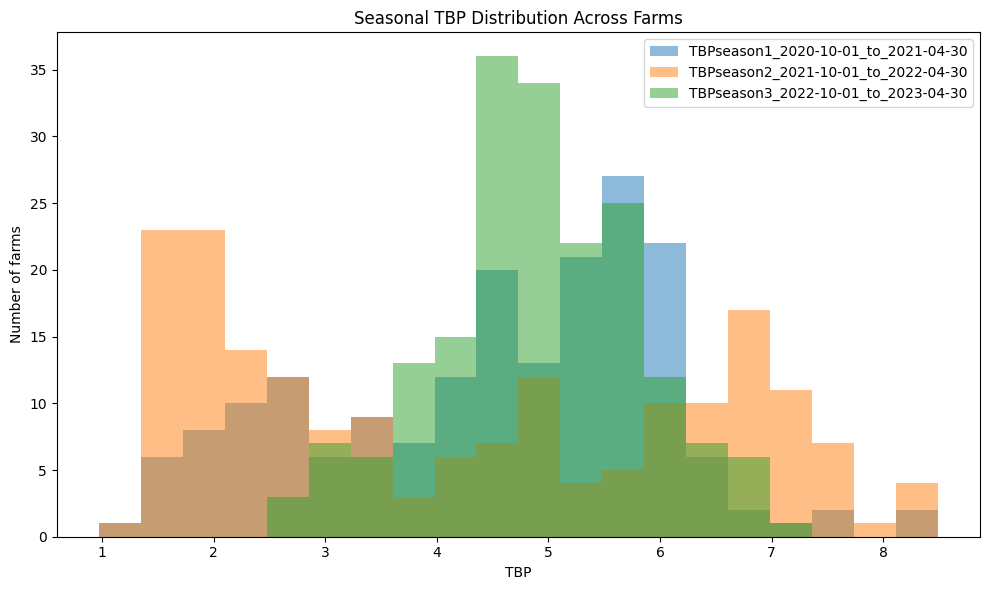

In [57]:
import matplotlib.pyplot as plt

season_cols = [
    'TBPseason1_2020-10-01_to_2021-04-30',
    'TBPseason2_2021-10-01_to_2022-04-30',
    'TBPseason3_2022-10-01_to_2023-04-30'
]

tbp_data[season_cols].plot(
    kind='hist', bins=20, alpha=0.5, figsize=(10, 6)
)

plt.title('Seasonal TBP Distribution Across Farms')
plt.xlabel('TBP')
plt.ylabel('Number of farms')
plt.tight_layout()
plt.show()

In [58]:

import pandas as pd

aeti_path = (
    '/content/drive/MyDrive/Python_mooc/Data/'
    'Zonal_Statistics/AETI_zonal_statistics.csv'
)

tbp_path = (
    '/content/drive/MyDrive/Python_mooc/Data/'
    'Zonal_Statistics/TBP_zonal_statistics.csv'
)

aeti_data = pd.read_csv(aeti_path)
tbp_data = pd.read_csv(tbp_path)

# Merge using the farm ID
merged_data = pd.merge(
    aeti_data,
    tbp_data,
    on='id',
    suffixes=('_AETI', '_TBP')
)

print("Merged DataFrame shape:", merged_data.shape)
print("\nMerged DataFrame attributes (columns):")
print(merged_data.columns.tolist())

print("\nDataFrame information:")
merged_data.info()

display(merged_data.head())


Merged DataFrame shape: (212, 13)

Merged DataFrame attributes (columns):
['id', 'yield_AETI', 'layer_AETI', 'path_AETI', 'AETIseason1_2020-10-01_to_2021-04-30', 'AETIseason2_2021-10-01_to_2022-04-30', 'AETIseason3_2022-10-01_to_2023-04-30', 'yield_TBP', 'layer_TBP', 'path_TBP', 'TBPseason1_2020-10-01_to_2021-04-30', 'TBPseason2_2021-10-01_to_2022-04-30', 'TBPseason3_2022-10-01_to_2023-04-30']

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    212 non-null    int64  
 1   yield_AETI                            212 non-null    float64
 2   layer_AETI                            212 non-null    object 
 3   path_AETI                             212 non-null    object 
 4   AETIseason1_2020-10-01_to_2021-04-30  187 non-null    float64
 5   

,id,yield_AETI,layer_AETI,path_AETI,AETIseason1_2020-10-01_to_2021-04-30,AETIseason2_2021-10-01_to_2022-04-30,AETIseason3_2022-10-01_to_2023-04-30,yield_TBP,layer_TBP,path_TBP,TBPseason1_2020-10-01_to_2021-04-30,TBPseason2_2021-10-01_to_2022-04-30,TBPseason3_2022-10-01_to_2023-04-30
0,3201,3.31,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,701.692308,528.279487,719.130769,3.31,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.142463,4.009081,5.356982
1,3202,3.10,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,725.018919,515.845946,775.375676,3.10,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.234155,4.046282,5.746220
2,3203,2.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,784.944118,555.411765,796.317647,2.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.884422,4.395098,6.155903
3,3204,3.30,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,771.600000,603.810000,784.365000,3.30,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,5.772654,5.004028,5.914560
4,3205,3.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,798.375000,599.495000,764.680000,3.32,BahiEddin11,D:/WA+/FAO_phase2/Python_for_geospatial_OCW/Fi...,6.042064,4.937746,5.634186


<div class="alert alert-success">

**Exercise 2**:

How many attributes does this new file have?

Note down this number, you need it for the MOOC quiz!

</div>


In [ ]:
# list attributes


The following script creates one scatterplot with the AETI in the x-axis and TBP on the y-axis with each season presented using different colors.

In [ ]:
# Plotting the scatter plot all in one figure
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['AETIseason1'], merged_data['TBPseason1'], alpha=0.6, edgecolors='w', color='red', label='Season1')
plt.scatter(merged_data['AETIseason2'], merged_data['TBPseason2'], alpha=0.6, edgecolors='w', color='green', label='Season2')
plt.scatter(merged_data['AETIseason3'], merged_data['TBPseason3'], alpha=0.6, edgecolors='w', color='blue', label='Season3')
plt.legend()
plt.title('Scatter Plot of AETI vs. TBP')
plt.xlabel('AETI (mm/season)')
plt.ylabel('Total Biomass Production (ton/ha/season)')
plt.grid(True)
plt.show()


If you want to create separate scatterplots for each season you have to create a `for` loop, as you can see below.



In [ ]:
# Plotting the scatter plot in separate figures
fig,axs = plt.subplots(nrows=1,ncols=3,figsize=(20, 6))
for i,season in enumerate(season_periods):
  axs[i].scatter(merged_data[f'AETI{season}'], merged_data[f'TBP{season}'], #name columns
                 alpha=0.6, edgecolors='w', color='blue') #
  axs[i].set_title(season)

  axs[i].set_xlabel('AETI (mm/season)')
  axs[i].set_ylabel('Total Biomass Production (ton/ha/season)')
  axs[i].grid(True)
plt.suptitle('Scatter Plot of AETI vs. TBP')
plt.savefig('/content/drive/MyDrive/Python_mooc/Data/AETIvsNPP.png') # saves the combined graphs
plt.show()


We also added a line to save the graph, can you find it? If you want to save each graph seperately, how would you do this? Consider sharing your graph(s) in the discussion forum. Change the style of the graph so we know you have mastered the materials.  

<div class="alert alert-success">


**Exercise 3**:

Season 3 has less scattered values compared to the other two seasons. What could be the reason for this?

1. The weather was better in season 3 compared to the other seasons
2. The crop type was consistent in season 3 (all fields were cropped with Wheat)
3. Irrigation water application was more uniform in season 3
4. Cropping season in season 1 and 2 was not well defined

Note down your answer, you need it in the MOOC quiz
</div>

<div class="alert alert-success">

**BONUS**: Add columns of seasonal water productivity to the DataFrame.

</div>

<div class="alert alert-success">

**BONUS**: Can you make a scatter plot for season 3 with each tertiary unit visualised with different colors? Share your result with us in the discussion forum.

</div>